# Thread 2: Gender Injustice

### This thread looks at the crimes against women in the past decade and concludes important pointers from it. For ex- how the rate of crime against women is affected each year, whether criminals are convicted, etc.

## Analysis

# Importing Libraries

In [36]:
import sys
sys.path.append("..")
import utility as u
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import importlib
importlib.reload(u)

<module 'utility' from '/Users/bhavya/Documents/DS/The Committee Will Look Into It/02_Gender_Injustice/../utility.py'>

## Loading Data files

In [37]:
csv1= u.load_data("data/cleaned/file1.csv")
csv2= u.load_data("data/cleaned/file2.csv")
csv3= u.load_data("data/cleaned/file3.csv")
csv4= u.load_data("data/cleaned/file4.csv")
csv5= u.load_data("data/cleaned/file5.csv")
csv6= u.load_data("data/cleaned/file6.csv")
csv7= u.load_data("data/cleaned/file7.csv")

## d. csv4 Analysis

In [38]:
csv4.columns

Index(['Cities', 'Population as of 2011', 'Rate of crime (%)',
       'Chargesheet rate (%)', 'year', 'crime_cases'],
      dtype='object')

Chart saved- charts/csv4_01_crime_vs_chargesheet_bubblechart.png


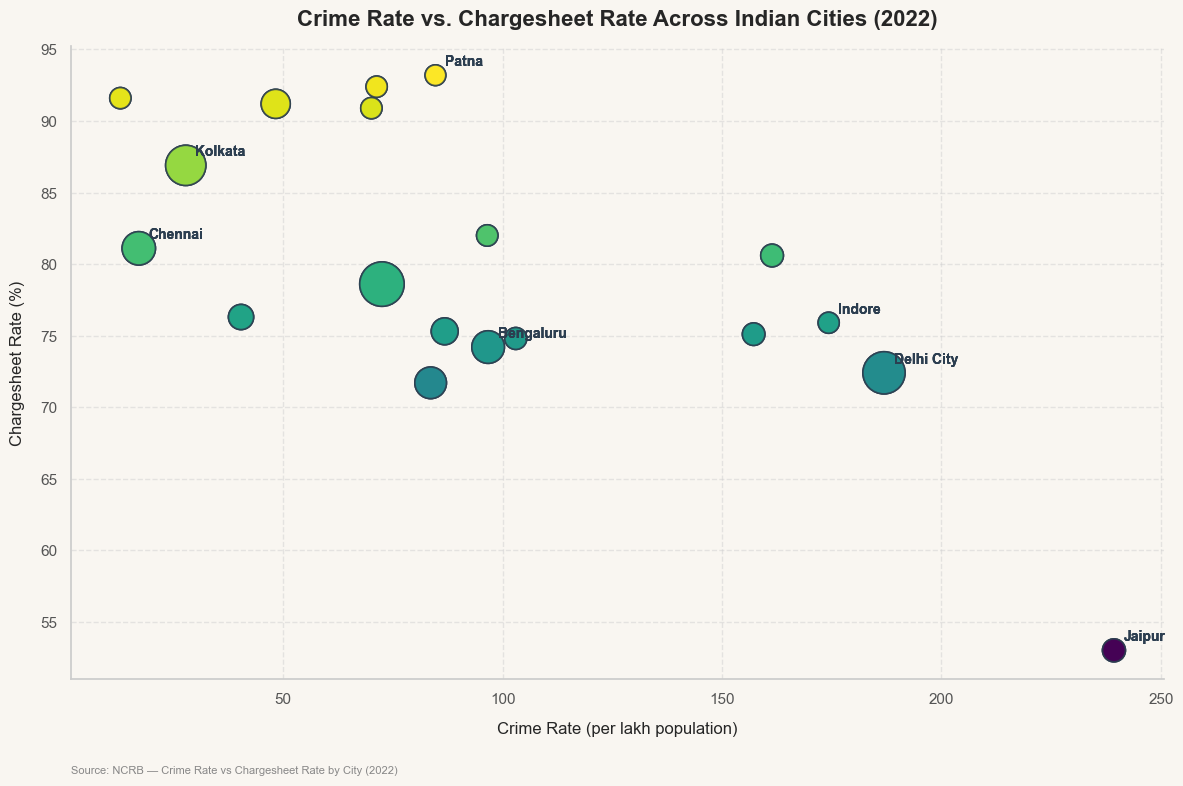

In [39]:
u.set_style()
fig, ax = plt.subplots(figsize=(12, 8))
fig.patch.set_facecolor(u.BG_COLOR)
ax.set_facecolor(u.BG_COLOR)

latest_year = csv4["year"].max()
x = csv4["Rate of crime (%)"]
y = csv4["Chargesheet rate (%)"]
pop = csv4["Population as of 2011"]

sizes = (pop / pop.max()) * 900 + 120

scatter = ax.scatter(
    x,
    y,
    s=sizes,
    c=y,
    cmap="viridis",
    alpha=0.8,
    edgecolor="#2c3e50",
    linewidth=1.2,
)

for i, row in csv4.iterrows():
  city = row["Cities"]
  xi, yi = row["Rate of crime (%)"], row["Chargesheet rate (%)"]
  if city in [
      "Jaipur",
      "Indore",
      "Delhi City",
      "Patna",
      "Chennai",
      "Kolkata",
      "Bengaluru",
  ]:
    ax.annotate(
        city,
        xy=(xi, yi),
        xytext=(7, 7),
        textcoords="offset points",
        fontsize=10,
        fontweight="bold",
        color="#2c3e50",
    )

ax.set_title(
    f"Crime Rate vs. Chargesheet Rate Across Indian Cities ({latest_year})",
    fontsize=16,
    fontweight="bold",
    pad=15,
)
ax.set_xlabel("Crime Rate (per lakh population)", fontsize=12)
ax.set_ylabel("Chargesheet Rate (%)", fontsize=12)

ax.grid(True, linestyle="--", alpha=0.5, color="#d0d0d0")

u.add_source(
    ax,
    f"NCRB — Crime Rate vs Chargesheet Rate by City ({latest_year})",
)

plt.tight_layout()
u.save_fig(fig, "charts", "csv4_01_crime_vs_chargesheet_bubblechart.png")
plt.show()

Chart saved- charts/csv4_02_city_crime_grouped_bargraph.png


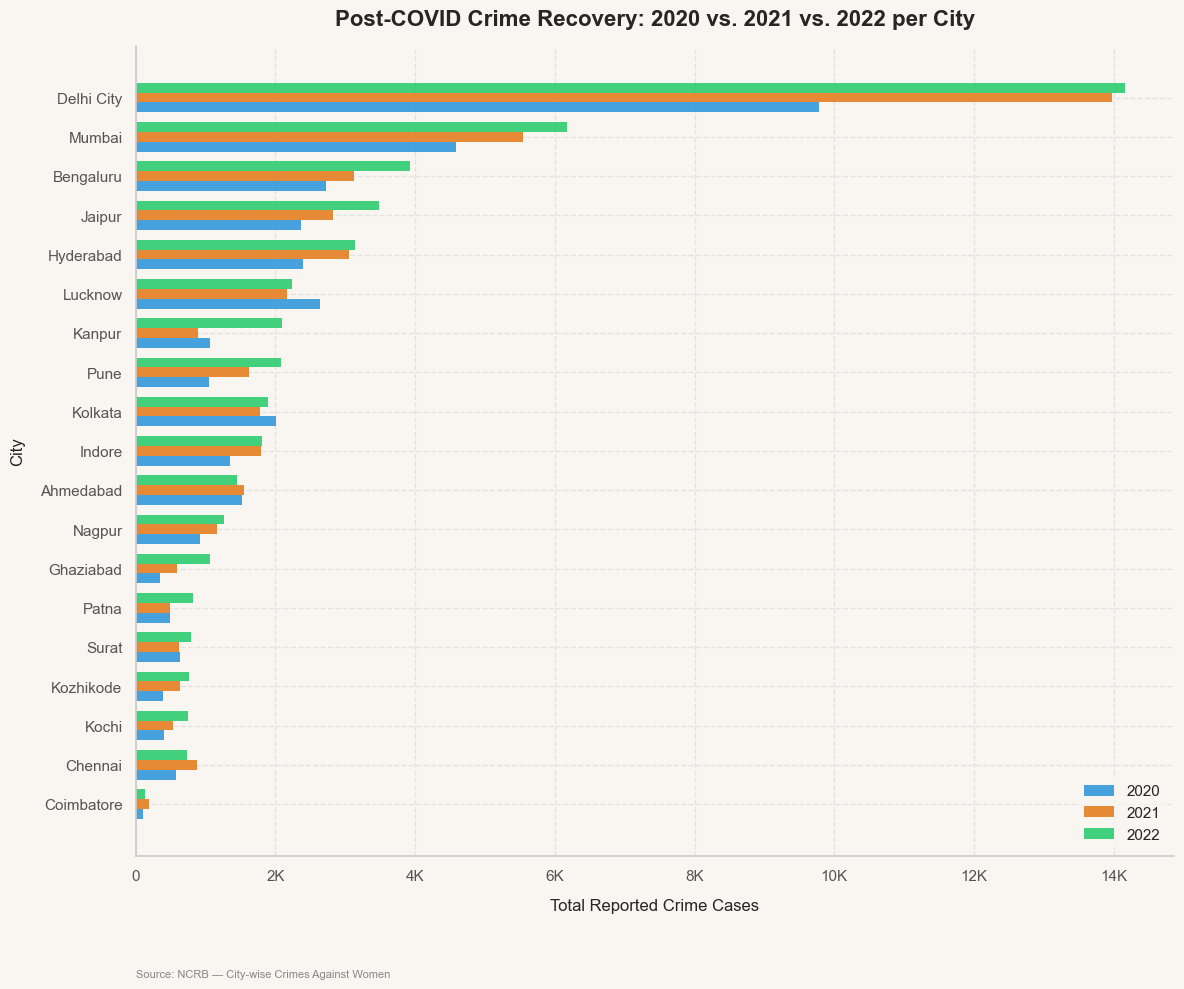

In [40]:
u.set_style()

pivot_df = csv4.pivot(
    index="Cities", columns="year", values="crime_cases"
).fillna(0)
pivot_df = pivot_df.sort_values(by=2022, ascending=True)

fig, ax = plt.subplots(figsize=(12, 10))
fig.patch.set_facecolor(u.BG_COLOR)
ax.set_facecolor(u.BG_COLOR)

y = np.arange(len(pivot_df))
height = 0.25

ax.barh(
    y - height,
    pivot_df[2020],
    height,
    label="2020",
    color="#3498db",
    edgecolor="none",
    alpha=0.9,
)
ax.barh(
    y,
    pivot_df[2021],
    height,
    label="2021",
    color="#e67e22",
    edgecolor="none",
    alpha=0.9,
)
ax.barh(
    y + height,
    pivot_df[2022],
    height,
    label="2022",
    color="#2ecc71",
    edgecolor="none",
    alpha=0.9,
)

ax.set_yticks(y)
ax.set_yticklabels(pivot_df.index, fontsize=11)
ax.set_title(
    "Post-COVID Crime Recovery: 2020 vs. 2021 vs. 2022 per City",
    fontsize=16,
    fontweight="bold",
    pad=15,
)
ax.set_xlabel("Total Reported Crime Cases", fontsize=12)
ax.set_ylabel("City", fontsize=12)

ax.xaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda x, pos: f"{x/1e3:.0f}K" if x >= 1e3 else f"{x:.0f}"
    )
)
ax.legend(
    frameon=True, facecolor=u.BG_COLOR, edgecolor="none", fontsize=11, loc="lower right"
)
ax.grid(True, linestyle="--", alpha=0.5, color="#d0d0d0")

u.add_source(ax, "NCRB — City-wise Crimes Against Women")

plt.tight_layout()
u.save_fig(fig, "charts", "csv4_02_city_crime_grouped_bargraph.png")
plt.show()

Chart saved- charts/csv4_03_city_crime_rate_bargraph.png


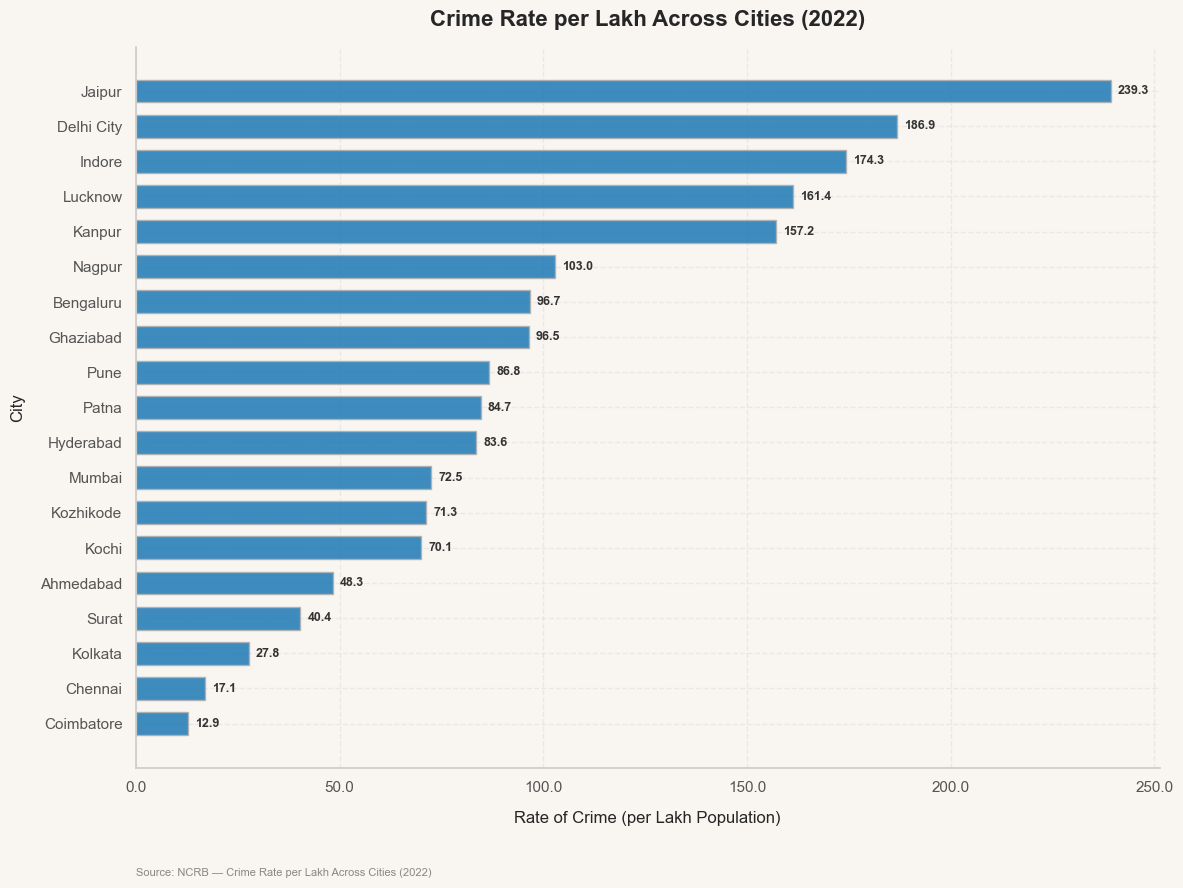

In [41]:
u.set_style()

csv4_2022 = csv4[csv4["year"] == 2022].copy()


# Sort by Rate of crime (%) ascending so lowest is at bottom, highest at top in barh
city_rates = csv4_2022.sort_values(by="Rate of crime (%)", ascending=True)

fig, ax = plt.subplots(figsize=(12, 9))
fig.patch.set_facecolor(u.BG_COLOR)
ax.set_facecolor(u.BG_COLOR)

bars = ax.barh(
    city_rates["Cities"],
    city_rates["Rate of crime (%)"],
    color="#2980b9",
    height=0.65,
    edgecolor="#b0b0b0",
    alpha=0.9,
)

ax.set_title(
    "Crime Rate per Lakh Across Cities (2022)",
    fontsize=16,
    fontweight="bold",
    pad=15,
)
ax.set_xlabel("Rate of Crime (per Lakh Population)", fontsize=12)
ax.set_ylabel("City", fontsize=12)

ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f"{x:.1f}"))

for bar in bars:
  width = bar.get_width()
  ax.annotate(
      f"{width:.1f}",
      xy=(width, bar.get_y() + bar.get_height() / 2),
      xytext=(5, 0),
      textcoords="offset points",
      ha="left",
      va="center",
      fontsize=9,
      fontweight="bold",
      color="#333333",
  )

u.add_source(ax, "NCRB — Crime Rate per Lakh Across Cities (2022)")

plt.tight_layout()
u.save_fig(fig, "charts", "csv4_03_city_crime_rate_bargraph.png")
plt.show()

## e. csv7 Analysis

In [42]:
csv7.columns

Index(['Category', 'State/UT', 'Offense_Category', 'Offense_Subcategory',
       'Incidents'],
      dtype='object')

In [43]:
csv7['State/UT'].unique()

array(['Andhra Pradesh', 'Arunachal Pradesh', 'Assam', 'Bihar',
       'Chhattisgarh', 'Goa', 'Gujarat', 'Haryana', 'Himachal Pradesh',
       'Jammu & Kashmir', 'Jharkhand', 'Karnataka', 'Kerala',
       'Madhya Pradesh', 'Maharashtra', 'Manipur', 'Meghalaya', 'Mizoram',
       'Nagaland', 'Odisha', 'Punjab', 'Rajasthan', 'Sikkim',
       'Tamil Nadu', 'Telangana', 'Tripura', 'Uttar Pradesh',
       'Uttarakhand', 'West Bengal', 'Andaman & Nicobar Islands',
       'Chandigarh', 'Dadra & Nagar Haveli', 'Daman & Diu', 'Delhi',
       'Lakshadweep', 'Puducherry'], dtype=object)

Chart saved- charts/csv7_01_state_rape_cases_bar.png


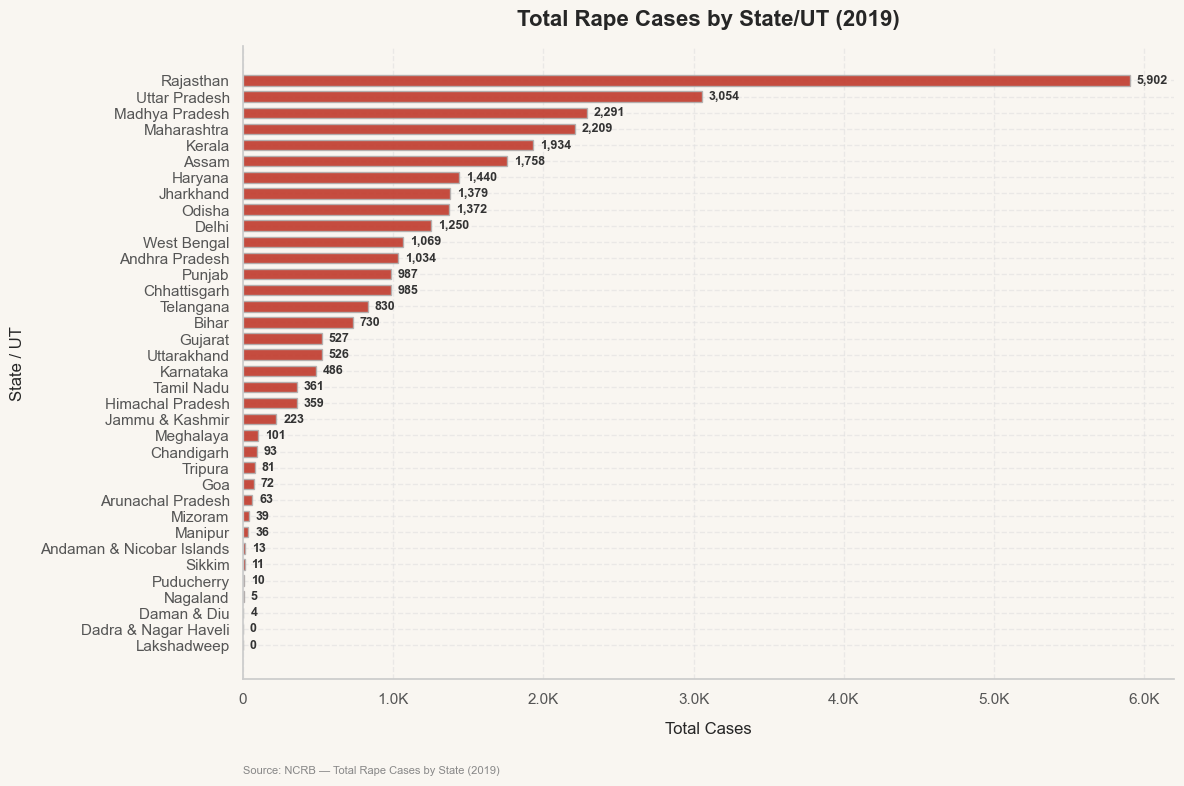

In [44]:
u.set_style()

# Group by State/UT to get total rape cases and sort for the horizontal bar
state_totals = (
    csv7.groupby("State/UT")["Incidents"]
    .sum()
    .sort_values(ascending=True)
)


fig, ax = plt.subplots(figsize=(12, 8))
fig.patch.set_facecolor(u.BG_COLOR)
ax.set_facecolor(u.BG_COLOR)

# Using a stark red to emphasize the severity of the data
bars = ax.barh(
    state_totals.index,
    state_totals.values,
    color="#c0392b",
    height=0.65,
    edgecolor="#b0b0b0",
    alpha=0.9,
)

ax.set_title(
    "Total Rape Cases by State/UT (2019)",
    fontsize=16,
    fontweight="bold",
    pad=15,
)
ax.set_xlabel("Total Cases", fontsize=12)
ax.set_ylabel("State / UT", fontsize=12)

ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, pos: f"{x/1e3:.1f}K" if x >= 1e3 else f"{x:.0f}")
)

for bar in bars:
    width = bar.get_width()
    ax.annotate(
        f"{width:,.0f}",
        xy=(width, bar.get_y() + bar.get_height() / 2),
        xytext=(5, 0),
        textcoords="offset points",
        ha="left",
        va="center",
        fontsize=9,
        fontweight="bold",
        color="#333333",
    )

u.add_source(ax, "NCRB — Total Rape Cases by State (2019)")

plt.tight_layout()
u.save_fig(fig, "charts", "csv7_01_state_rape_cases_bar.png")
plt.show()

Chart saved- charts/csv7_02_rape_type_composition_by_state.png


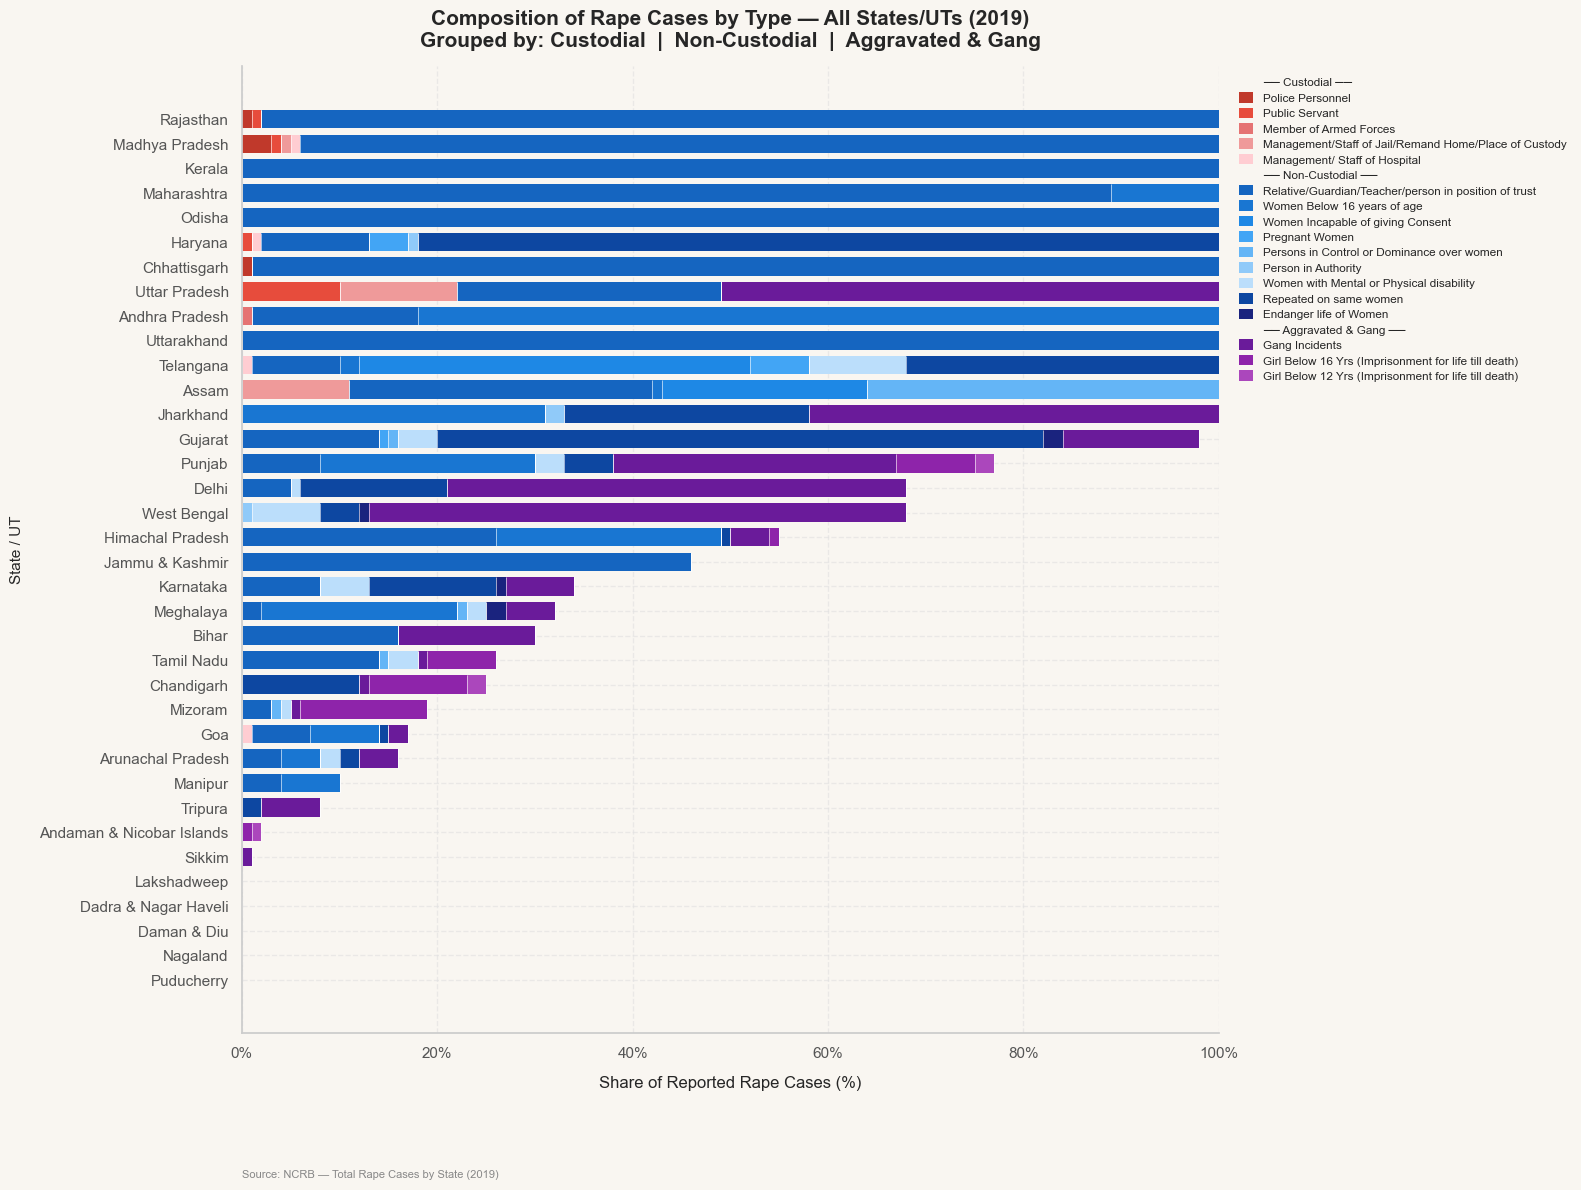

In [45]:
u.set_style()

# 1. Exclude "Penalties & Legal Provisions" as those are sentencing labels,
# not offense types; including them would misrepresent totals
offense_df = csv7[~csv7["Offense_Category"].isin(["Penalties & Legal Provisions"])].copy()

# 2. Collapse to State × Subcategory totals
pivot = (
    offense_df
    .groupby(["State/UT", "Offense_Subcategory"])["Incidents"]
    .sum()
    .unstack(fill_value=0)
)

pivot["_total"] = pivot.sum(axis=1)
pivot = pivot.sort_values("_total", ascending=True).drop(columns="_total")

COL_ORDER = [
    # Custodial
    "Police Personnel",
    "Public Servant",
    "Member of Armed Forces",
    "Management/Staff of Jail/Remand Home/Place of Custody",
    "Management/ Staff of Hospital",
    # Non-Custodial
    "Relative/Guardian/Teacher/person in position of trust",
    "Women Below 16 years of age",
    "Women Incapable of giving Consent",
    "Pregnant Women",
    "Persons in Control or Dominance over women",
    "Person in Authority",
    "Women with Mental or Physical disability",
    "Repeated on same women",
    "Endanger life of Women",
    # Aggravated & Gang
    "Gang Incidents",
    "Girl Below 16 Yrs (Imprisonment for life till death)",
    "Girl Below 12 Yrs (Imprisonment for life till death)",
]
# only keep cols that exist in data
COL_ORDER = [c for c in COL_ORDER if c in pivot.columns]
pivot = pivot[COL_ORDER]

#        Custodial = reds (5), Non-Custodial = blues (9), Aggravated = purples (3)
COLORS = [
    # Custodial
    "#c0392b", "#e74c3c", "#e57373", "#ef9a9a", "#ffcdd2",
    # Non-Custodial
    "#1565c0", "#1976d2", "#1e88e5", "#42a5f5", "#64b5f6",
    "#90caf9", "#bbdefb", "#0d47a1", "#1a237e",
    # Aggravated & Gang
    "#6a1b9a", "#8e24aa", "#ab47bc",
]


fig, ax = plt.subplots(figsize=(16, 12))
fig.patch.set_facecolor(u.BG_COLOR)
ax.set_facecolor(u.BG_COLOR)

lefts = np.zeros(len(pivot))
bars_handles = []
for col, color in zip(COL_ORDER, COLORS):
    vals = pivot[col].values
    bar = ax.barh(
        pivot.index,
        vals,
        left=lefts,
        color=color,
        edgecolor="none",
        height=0.75,
        label=col,
    )
    bars_handles.append(bar)
    lefts += vals

    # thin boundary at the right edge of each segment
    ax.vlines(
        x=lefts,
        ymin=np.arange(len(pivot)) - 0.375,
        ymax=np.arange(len(pivot)) + 0.375,
        colors="white",
        linewidth=0.6,
        alpha=0.7,
    )

ax.set_xlim(0, 100)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))
ax.set_xlabel("Share of Reported Rape Cases (%)", fontsize=12)
ax.set_ylabel("State / UT", fontsize=11)
ax.set_title(
    "Composition of Rape Cases by Type — All States/UTs (2019)\n"
    "Grouped by: Custodial  |  Non-Custodial  |  Aggravated & Gang",
    fontsize=15,
    fontweight="bold",
    pad=14,
)

from matplotlib.lines import Line2D
divider = Line2D([0], [0], color="none")  # invisible spacer

legend_handles = []
legend_labels  = []

sections = {
    "── Custodial ──": slice(0, 5),
    "── Non-Custodial ──": slice(5, 14),
    "── Aggravated & Gang ──": slice(14, 17),
}
for section_label, slc in sections.items():
    legend_handles.append(divider)
    legend_labels.append(section_label)
    for col, color in zip(COL_ORDER[slc], COLORS[slc]):
        legend_handles.append(plt.Rectangle((0, 0), 1, 1, fc=color, ec="none"))
        legend_labels.append(col)

ax.legend(
    legend_handles,
    legend_labels,
    bbox_to_anchor=(1.01, 1),
    loc="upper left",
    frameon=False,
    fontsize=8.5,
    handlelength=1.2,
    handleheight=1.0,
    borderpad=0.4,
    labelspacing=0.35,
)

u.add_source(ax, "NCRB — Total Rape Cases by State (2019)")

plt.tight_layout()
u.save_fig(fig, "charts", "csv7_02_rape_type_composition_by_state.png")
plt.show()

Chart saved- charts/csv7_04_custodial_rape_subcategories.png


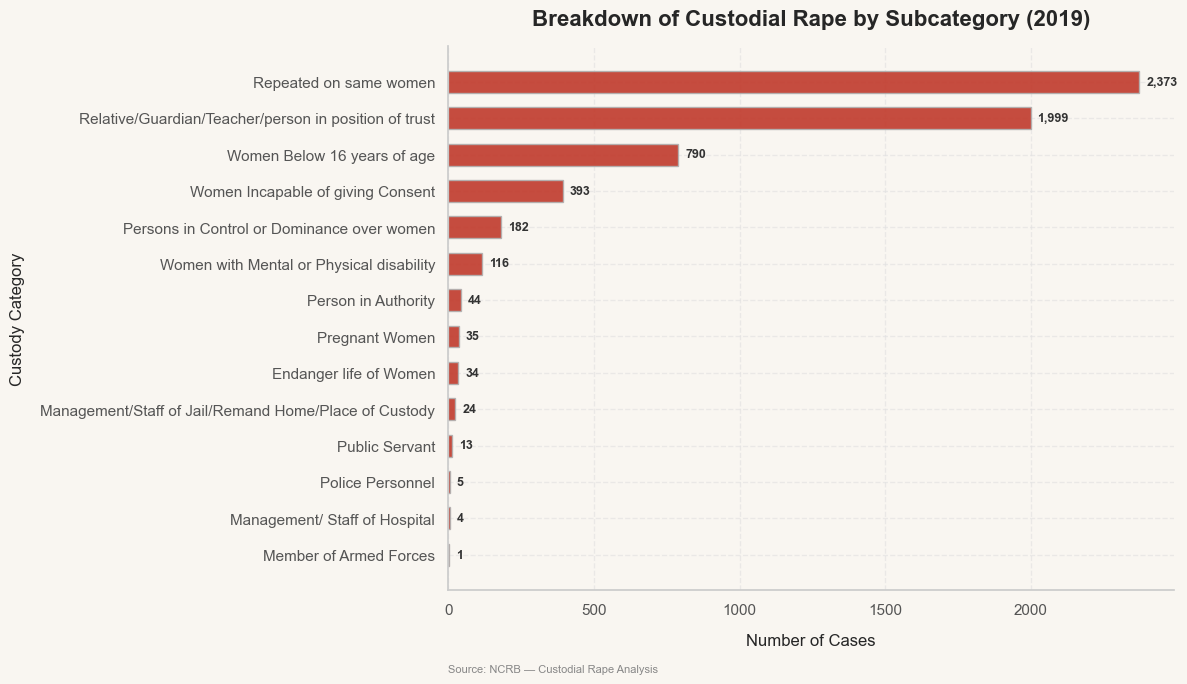

In [46]:
u.set_style()

# Filter for Custodial Rape records and aggregate by custody subcategories
custodial_df = csv7[csv7['Offense_Category'].str.contains("Custodial", case=False, na=False)]
subcat_totals = custodial_df.groupby('Offense_Subcategory')["Incidents"].sum().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor(u.BG_COLOR)
ax.set_facecolor(u.BG_COLOR)

bars = ax.barh(
    subcat_totals.index,
    subcat_totals.values,
    color="#c0392b",
    height=0.6,
    edgecolor="#b0b0b0",
    alpha=0.9,
)

ax.set_title(
    "Breakdown of Custodial Rape by Subcategory (2019)",
    fontsize=16,
    fontweight="bold",
    pad=15,
)
ax.set_xlabel("Number of Cases", fontsize=12)
ax.set_ylabel("Custody Category", fontsize=12)

for bar in bars:
    width = bar.get_width()
    ax.annotate(
        f"{width:,.0f}",
        xy=(width, bar.get_y() + bar.get_height() / 2),
        xytext=(5, 0),
        textcoords="offset points",
        ha="left",
        va="center",
        fontsize=9,
        fontweight="bold",
        color="#333333",
    )

u.add_source(ax, "NCRB — Custodial Rape Analysis")

plt.tight_layout()
u.save_fig(fig, "charts", "csv7_04_custodial_rape_subcategories.png")
plt.show()

Chart saved- charts/csv7_05_UP_custodial_rape.png


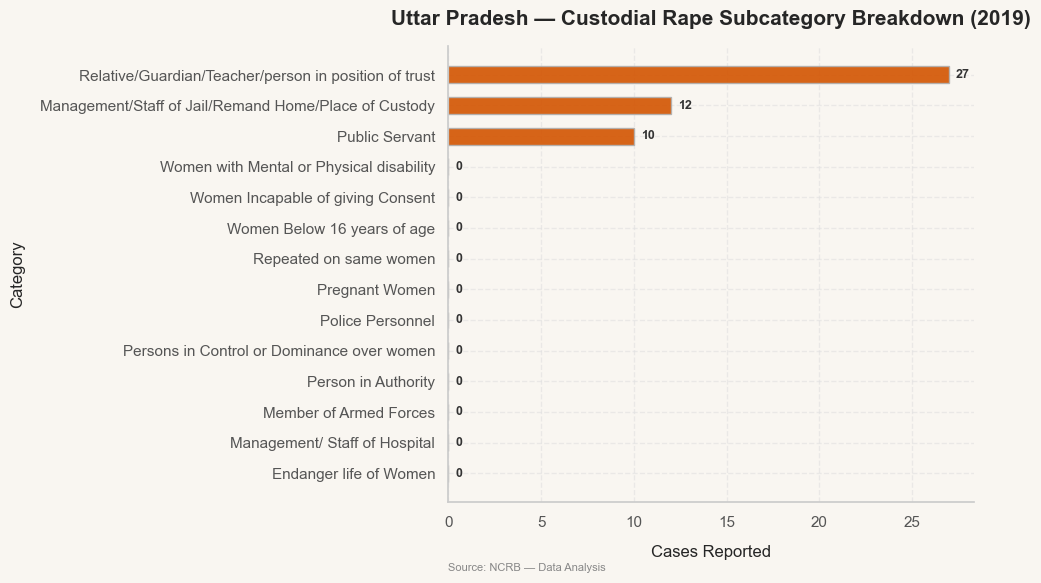

In [47]:
# Filter specifically for Uttar Pradesh custodial rape subcategories
up_custodial = csv7[
    (csv7["State/UT"].str.upper() == "UTTAR PRADESH") & 
    (csv7['Offense_Category'].str.contains("Custodial", case=False, na=False))
]

up_subcats = up_custodial.groupby("Offense_Subcategory")["Incidents"].sum().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(u.BG_COLOR)
ax.set_facecolor(u.BG_COLOR)

bars = ax.barh(
    up_subcats.index,
    up_subcats.values,
    color="#d35400",
    height=0.55,
    edgecolor="#b0b0b0",
    alpha=0.9,
)

ax.set_title(
    "Uttar Pradesh — Custodial Rape Subcategory Breakdown (2019)",
    fontsize=15,
    fontweight="bold",
    pad=15,
)
ax.set_xlabel("Cases Reported", fontsize=12)
ax.set_ylabel("Category", fontsize=12)

for bar in bars:
    width = bar.get_width()
    ax.annotate(
        f"{width:,.0f}",
        xy=(width, bar.get_y() + bar.get_height() / 2),
        xytext=(5, 0),
        textcoords="offset points",
        ha="left",
        va="center",
        fontsize=9,
        fontweight="bold",
        color="#333333",
    )

u.add_source(ax, "NCRB — Data Analysis")

plt.tight_layout()
u.save_fig(fig, "charts", "csv7_05_UP_custodial_rape.png")
plt.show()

Chart saved- charts/csv7_06_minor_crimes_bar.png


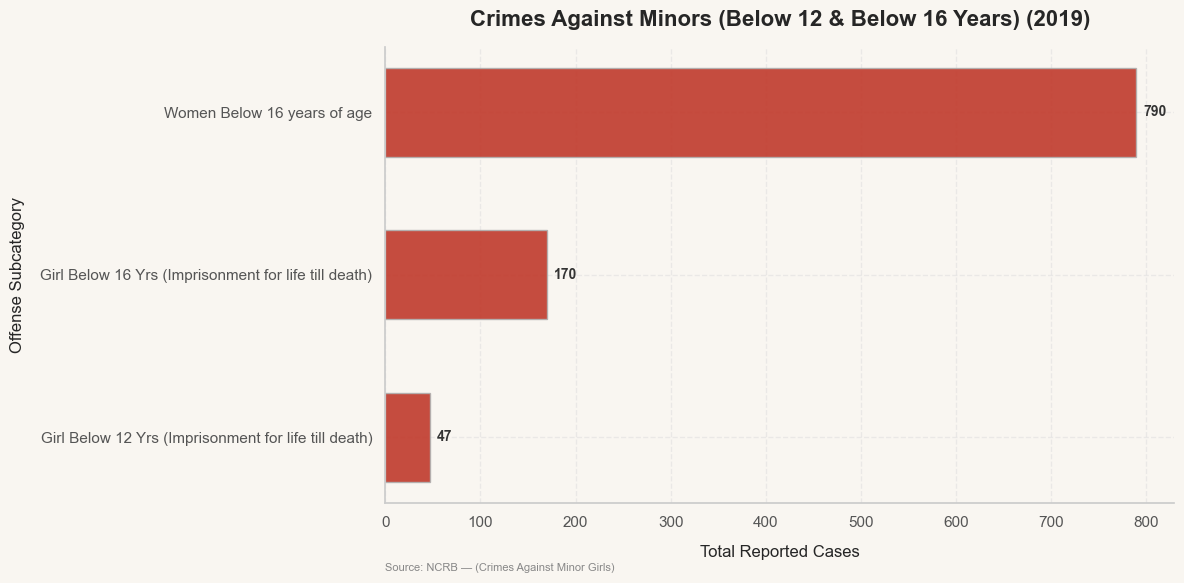

In [48]:
u.set_style()

# Filter specifically for minor protection offense subcategories
minor_categories = [
    "Girl Below 12 Yrs (Imprisonment for life till death)",
    "Girl Below 16 Yrs (Imprisonment for life till death)",
    "Women Below 16 years of age",
]

df_minors = csv7[csv7["Offense_Subcategory"].isin(minor_categories)]


# Aggregate total cases by offense category
category_totals = (
    df_minors.groupby("Offense_Subcategory")['Incidents']
    .sum()
    .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor(u.BG_COLOR)
ax.set_facecolor(u.BG_COLOR)

bars = ax.barh(
    category_totals.index,
    category_totals.values,
    color="#c0392b",
    height=0.55,
    edgecolor="#b0b0b0",
    alpha=0.9,
)

ax.set_title(
    "Crimes Against Minors (Below 12 & Below 16 Years) (2019)",
    fontsize=16,
    fontweight="bold",
    pad=15,
)
ax.set_xlabel("Total Reported Cases", fontsize=12)
ax.set_ylabel("Offense Subcategory", fontsize=12)

# X-axis number formatting
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda x, pos: f"{x/1e3:.0f}K" if x >= 1e3 else f"{x:.0f}"
    )
)

for bar in bars:
  width = bar.get_width()
  ax.annotate(
      f"{width:,.0f}",
      xy=(width, bar.get_y() + bar.get_height() / 2),
      xytext=(5, 0),
      textcoords="offset points",
      ha="left",
      va="center",
      fontsize=10,
      fontweight="bold",
      color="#333333",
  )

u.add_source(
    ax, "NCRB — (Crimes Against Minor Girls)"
)

plt.tight_layout()
u.save_fig(fig, "charts", "csv7_06_minor_crimes_bar.png")
plt.show()

## f. csv5 Analysis

Chart saved- charts/csv5_01_arrest_to_conviction_pipeline.png


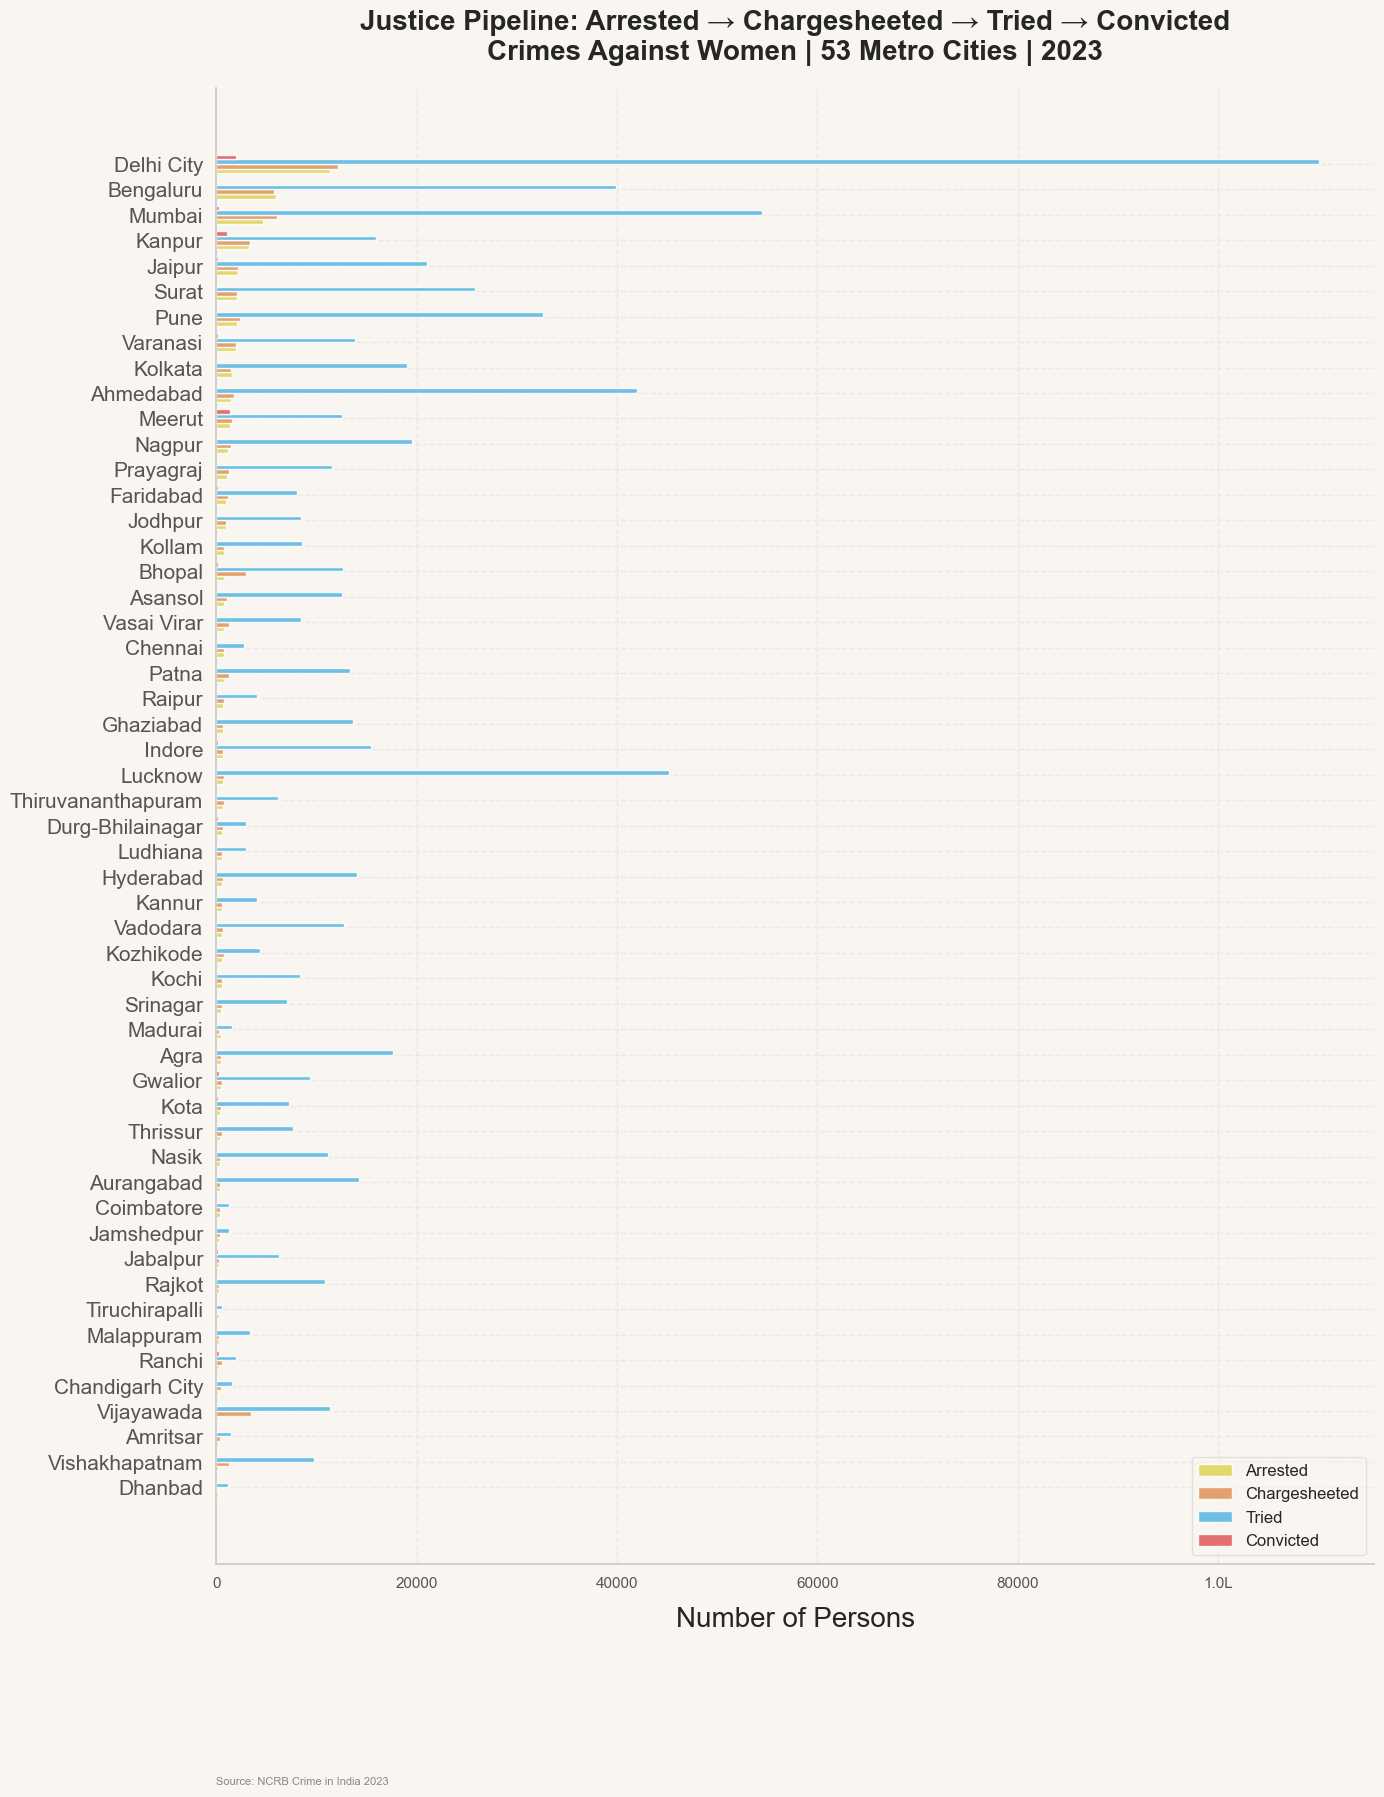

In [49]:
# Pipeline stages in logical order (both genders combined)
PIPELINE_STAGES = [
    "Persons Arrested in Cases Registered during the year",
    "Persons Arrested and Chargesheeted",
    "Persons in whose cases Trials were completed",
    "Persons Convicted",
]
STAGE_LABELS = ["Arrested", "Chargesheeted", "Tried", "Convicted"]
STAGE_COLORS = ["#e0d45c", "#e0955c", "#5cb8e0", "#e05c5c"]

# Aggregate both genders, keep only the 4 pipeline stages
pipe = (
    csv5[csv5["Crime"].isin(PIPELINE_STAGES)]
    .groupby(["city", "Crime"])["person_count"]
    .sum()
    .reset_index()
)
pipe["Stage"] = pipe["Crime"].map(dict(zip(PIPELINE_STAGES, STAGE_LABELS)))


pivot = (
    pipe.pivot(index="city", columns="Stage", values="person_count")
    [STAGE_LABELS]  
    .fillna(0)
    .sort_values("Arrested", ascending=True)   
)

u.set_style()
fig, ax = plt.subplots(figsize=(14, 18))
fig.patch.set_facecolor(u.BG_COLOR)
ax.set_facecolor(u.BG_COLOR)

y = range(len(pivot))
bar_h = 0.18
offsets = [-1.5, -0.5, 0.5, 1.5]

for i, (stage, color) in enumerate(zip(STAGE_LABELS, STAGE_COLORS)):
    bars = ax.barh(
        [yi + offsets[i] * bar_h for yi in y],
        pivot[stage],
        height=bar_h,
        label=stage,
        color=color,
        alpha=0.88,
    )

ax.set_yticks(list(y))
ax.set_yticklabels(pivot.index, fontsize=15)
ax.set_xlabel("Number of Persons", fontsize=20)
ax.set_title(
    "Justice Pipeline: Arrested → Chargesheeted → Tried → Convicted\nCrimes Against Women | 53 Metro Cities | 2023",
    fontsize=20, fontweight="bold", pad=20
)
ax.legend(loc="lower right", fontsize=12, framealpha=0.5)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(u.lakh_formatter))
u.add_source(ax, "NCRB Crime in India 2023")
plt.tight_layout()

u.save_fig(fig, "charts", "csv5_01_arrest_to_conviction_pipeline.png")
plt.show()